<a href="https://colab.research.google.com/github/mariabraga20012004-cloud/analise-datahackers-2022/blob/main/analise_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUÇÃO

Este projeto apresenta uma análise técnica e estatística baseada nos dados da pesquisa anual do DataHackers de 2022. O principal objetivo é extrair insights relevantes sobre o ecossistema de Tecnologia da Informação no Brasil, identificando padrões de remuneração, tendências de contratação e aspectos relacionados à diversidade e inclusão no setor.

Para garantir a qualidade e a consistência das análises apresentadas neste notebook, o fluxo de trabalho foi estruturado em pilares fundamentais, como Estatística Descritiva e Análise Exploratória de Dados, Qualidade e Tratamento de Dados, Enriquecimento de Dados, Feature Engineering e Boas Práticas de Documentação.

Utilizando o ecossistema Python — com bibliotecas como Pandas, NumPy, Matplotlib, Seaborn e Plotly — além da integração com SQL para enriquecimento das bases de dados, esta análise busca não apenas descrever o cenário atual do mercado de tecnologia, mas também fornecer uma base analítica consistente para compreensão das dinâmicas que influenciam o setor no Brasil.

### IMPORTAÇÕES

In [104]:
# MONTAGEM DO DRIVE (APENAS UMA VEZ!)
from google.colab import drive
drive.mount('/content/drive')

# IMPORTAÇÃO DE BIBLIOTECAS (TODAS NO TOPO)
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency



# CARREGAMENTO DO DATASET PRINCIPAL
dados = pd.read_csv('/content/drive/MyDrive/PROGR{M}ARIA/analise_dado.csv')
# CONEXÃO COM O BANCO DE DADOS SQL
conexao = sqlite3.connect('/content/drive/MyDrive/PROGR{M}ARIA/status_brasil')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##ANÁLISE EXPLORATÓRIA DE DADOS

**OBJETIVO:** Carregar, estruturar e realizar a exploração inicial do dataset.


In [2]:
# CARREGAMENTO DO DATASET A PARTIR DO EXCEL
# DEFINIMOS O DATAFRAME COMO 'DADOS' PARA MANIPULAÇÃO
dados = pd.read_excel('/content/drive/MyDrive/PROGR{M}ARIA/planilha_modulo3.xlsx')

In [3]:
# MOSTRA A TABELA QUE NOMEAMOS DE DADOS, VER A TABELA INTEIRA.
dados

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0


In [4]:
# EXIBIÇÃO DAS 10 PRIMEIRAS LINHAS PARA VERIFICAÇÃO DA ESTRUTURA DOS DADOS
dados.head(10)

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
8,8,zy4o5dk6iuxpdwgzy4o58xvd6ykwohrj,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,7112.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0


In [5]:
# EXIBIÇÃO DAS ÚLTIMAS LINHAS PARA VERIFICAÇÃO DE FINAL DE ARQUIVO
dados.tail()

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0
4270,4270,00lb35llmdsidpa00lb35qcdysnzvhv7,24.0,22-24,Masculino,Branca,Não,NaN,NaN,True,...,Agronegócios,de 501 a 1.000,0.0,NaN,Analista de Dados/Data Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3079.0


In [6]:
# VERIFICAÇÃO DAS DIMENSÕES DO DATASET (LINHAS, COLUNAS)
print(f"DIMENSÕES DO DATASET: {dados.shape}")

DIMENSÕES DO DATASET: (4271, 28)


In [7]:
# LISTAGEM DE TODAS AS COLUNAS PRESENTES NO DATAFRAME
print(f"COLUNAS DISPONÍVEIS: {dados.columns.tolist()}")

COLUNAS DISPONÍVEIS: ['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS', 'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA', 'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR', 'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL', 'NIVEL', 'FAIXA SALARIAL', 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?', 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?', 'SALARIO']


In [8]:
# VER UMA COLUNA ESPECÍFICA. ABAIXO IREMOS VER A COLUNA COR/RACA/ETNIA.
dados['COR/RACA/ETNIA']

,COR/RACA/ETNIA
0,Parda
1,Parda
2,Branca
3,Branca
4,Branca
...,...
4266,Branca
4267,Branca
4268,Branca
4269,Branca


In [9]:
# ANÁLISE DE METADADOS: TIPOS DE DADOS, VALORES NULOS E MEMÓRIA
# ESSENCIAL PARA IDENTIFICAR NECESSIDADE DE LIMPEZA (DATA CLEANING)
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

In [10]:
# RESUMO ESTATÍSTICO DAS VARIÁVEIS NUMÉRICAS
# AUXILIA NA IDENTIFICAÇÃO DE TENDÊNCIA CENTRAL E DISPERSÃO DOS DADOS
dados.describe()

,Unnamed: 0,IDADE,MUDOU DE ESTADO?,GESTOR?,SALARIO
count,4271.000000,4197.000000,4171.000000,3694.000000,3694.000000
mean,2135.000000,31.169168,0.806281,0.193016,10969.266919
std,1233.075829,6.902803,0.395258,0.394719,19419.753189
min,0.000000,18.000000,0.000000,0.000000,35.000000
25%,1067.500000,26.000000,1.000000,0.000000,4269.500000
50%,2135.000000,30.000000,1.000000,0.000000,7625.500000
75%,3202.500000,35.000000,1.000000,0.000000,12778.500000
max,4270.000000,54.000000,1.000000,1.000000,485191.000000


##APLICAÇÃO DE FILTRAGEM E SEGMENTAÇÃO DE DADOS UTILIZANDO OPERADORES LÓGICOS
**OBJETIVO:** Isolar subconjuntos do dataset utilizando operadores lógicos e métodos de string.


#####FILTRAGEM DE DADOS POR GÊNERO

In [11]:
# SELECIONA APENAS REGISTROS DO GÊNERO FEMININO
dados_feminino = dados[dados['GENERO'] == 'Feminino']

In [12]:
# SELECIONA TODOS OS REGISTROS ONDE O GÊNERO É DIFERENTE DE 'MASCULINO'
# ÚTIL PARA IDENTIFICAR OUTRAS IDENTIDADES DE GÊNERO OU VALORES NÃO BINÁRIOS
dados_nao_masculino = dados[dados['GENERO'] != 'Masculino']

In [13]:
# FILTRA LINHAS ONDE A COLUNA GÊNERO CONTÉM A SUBSTRING "NÃO"
# O PARÂMETRO NA=FALSE EVITA ERROS CASO EXISTAM VALORES NULOS
dados_contem_nao = dados[dados['GENERO'].str.contains('não', na=False)]

#####FILTRAGEM DE DADOS POR IDADE E ETNIA

In [14]:
# SELECIONA PROFISSIONAIS COM IDADE ESTRITAMENTE MAIOR QUE 30 ANOS
dados_maior_30 = dados[dados['IDADE'] > 30]

In [15]:
# SELECIONA PROFISSIONAIS COM IDADE IGUAL OU SUPERIOR A 30 ANOS
dados_30_ou_mais = dados[dados['IDADE'] >= 30]

In [18]:
# FILTRA REGISTROS DE PESSOAS DA COR/RAÇA/ETNIA 'AMARELA'
dados_etnia_amarela = dados[dados['COR/RACA/ETNIA'] == 'Amarela']

#####FILTRAGEM DE DADOS POR IDADE, GÊNERO E ETNIA

In [19]:
# SELECIONA PESSOAS COM MAIS DE 30 ANOS QUE SÃO DO GÊNERO FEMININO
mulheres_mais_30 = dados[(dados['IDADE'] > 30) & (dados['GENERO'] == 'Feminino')]

In [21]:
# FILTRA PESSOAS DA ETNIA 'AMARELA' COM MENOS DE 40 ANOS
amarela_menos_40 = dados[(dados['COR/RACA/ETNIA'] == 'Amarela') & (dados['IDADE'] < 40)]

#####ANÁLISE DE DISTRIBUIÇÃO E CONTAGEM POR GÊNERO E NÍVEL

In [22]:
# CONTAGEM DE IDS ÚNICOS POR GÊNERO (IDENTIFICA QUANTIDADE REAL DE PESSOAS)
contagem_genero = dados.groupby('GENERO')['ID'].nunique()

In [23]:
# CONTAGEM POR GÊNERO INCLUINDO VALORES NULOS (DROPNA=FALSE)
# ESSENCIAL PARA AUDITORIA DE QUALIDADE E SANIDADE DOS DADOS
contagem_genero_nulos = dados.groupby('GENERO', dropna=False)['ID'].nunique()

In [24]:
# O GROUPBY COM NUNIQUE() SERVE PARA CONTAR ITENS SEM REPETIÇÃO, O QUE É IDEAL PARA SABER O NÚMERO REAL DE PESSOAS.
# JÁ O VALUE_COUNTS() É A FORMA MAIS RÁPIDA DE VER A DISTRIBUIÇÃO DE UMA CATEGORIA, E O DROPNA=FALSE AJUDA A IDENTIFICAR SE HÁ MUITOS DADOS FALTANDO NA COLUNA.
dados[dados['IDADE']>30]['NIVEL'].value_counts()

,count
NIVEL,
Sênior,525
Pleno,408
Júnior,274


In [25]:
# ANALISA A DISTRIBUIÇÃO DE CARGOS (NÍVEL) PARA MULHERES ACIMA DE 30 ANOS
dados[(dados['IDADE']>30) & (dados['GENERO'] == 'Feminino')] ['NIVEL'].value_counts()

,count
NIVEL,
Pleno,117
Sênior,114
Júnior,96


#####ANÁLISE DE LIDERANÇA POR GÊNERO E CARGO DE GESTÃO

In [ ]:
# TABELA DINÂMICA QUE CRUZA GÊNERO E CARGO DE GESTÃO PARA CONTAGEM DE PROFISSIONAIS
# O PRIMEIRO COMANDO AJUDA A IDENTIFICAR A SENIORIDADE DE UM GRUPO ESPECÍFICO
# ENQUANTO A PIVOT_TABLE CRIA UMA VISÃO EXECUTIVA (ESTILO EXCEL) QUE FACILITA A COMPARAÇÃO DIRETA ENTRE HOMENS E MULHERES EM POSIÇÕES DE LIDERANÇA.
pd.pivot_table(dados, values=['ID'], index=['GENERO'], columns=['GESTOR?'], aggfunc='count')

In [ ]:
# DEFINIÇÃO DE MÁSCARAS PARA FILTRAGEM DE DADOS
# USAR VARIÁVEIS PARA OS FILTROS MELHORA A LEGIBILIDADE E MANUTENÇÃO DO CÓDIGO
filtro_idade_30 = dados['IDADE'] > 30
filtro_genero_feminino = dados['GENERO'] == 'Feminino'

# APLICAÇÃO DOS FILTROS COMBINADOS
dados_mulheres_mais_30 = dados[filtro_idade_30 & filtro_genero_feminino]

In [ ]:
# EXIBIÇÃO DA DISTRIBUIÇÃO DE NÍVEIS PARA ESSE SEGMENTO
# O VALUE_COUNTS() MOSTRA A FREQUÊNCIA DE CADA CARGO NESSE GRUPO
print("DISTRIBUIÇÃO DE CARGOS - MULHERES > 30 ANOS:")
display(dados_mulheres_mais_30['NIVEL'].value_counts())

In [ ]:
# TABELA DINÂMICA: CRUZAMENTO DE GÊNERO POR GESTOR
# UTILIZAMOS A PIVOT_TABLE PARA UMA VISÃO EXECUTIVA DE LIDERANÇA
relatorio_lideranca = pd.pivot_table(
    dados,
    values='ID',
    index=['GENERO'],
    columns=['GESTOR'],
    aggfunc='count'
)

In [ ]:
# RENAME PARA MELHORAR A APRESENTAÇÃO DO RELATÓRIO
print("MATRIZ DE LIDERANÇA (GÊNERO X GESTOR):")
display(relatorio_lideranca)

##FUNDAMENTOS DE ESTATÍSTICA DESCRITIVA
**Objetivo:** Explorar métricas de estatística descritiva (como média, mediana e distribuição) para compreender os dados e realizar análises comparativas por faixa etária e gênero.

#####CARREGAMENTO E INSPEÇÃO DE DADOS

In [26]:
lista_idades = [12,15,30,35,40,45,21,31,33,10]

In [27]:
# DADOS E ORDENAÇÃO
lista_idades.sort()

In [28]:
# ADIÇÃO DE NOVOS DADOS AO DATASET UTILIZANDO O MÉTODO EXTEND
# UTILIZAMOS EXTEND PARA ADICIONAR MÚLTIPLOS ELEMENTOS À LISTA EXISTENTE
lista_idades.extend([100, 55])
lista_idades.sort()

In [29]:
# MÉTRICA DE TENDÊNCIA CENTRAL
media = np.mean(lista_idades)
mediana = np.median(lista_idades)

print(f"Média: {media}, Mediana: {mediana}")

Média: 35.583333333333336, Mediana: 32.0


#####ANÁLISE SALARIAL POR FAIXA ETÁRIA

In [30]:
# CÁLCULO DE MÉDIA E MEDIANA (TENDÊNCIA CENTRAL)
dados['IDADE'].mean()
dados['IDADE'].median()

30.0

In [31]:
# CÁLCULO DA MODA (VALOR MAIS FREQUENTE)
dados['IDADE'].mode()

,IDADE
0,27.0


In [32]:
# CÁLCULO DO DESVIO PADRÃO (DISPERSÃO DOS DADOS)
# QUANTO MAIS PRÓXIMO DE 0, MAIS HOMOGÊNEOS SÃO OS DADOS.
dados['IDADE'].std()

6.902802832143141

In [33]:
# IDENTIFICAÇÃO DE EXTREMOS (VALORES MÍNIMOS E MÁXIMOS)
dados['IDADE'].min()
dados['IDADE'].max()

54.0

#####ANÁLISE COMPARATIVA POR GÊNERO

In [34]:
# MÉDIA DE IDADE POR GÊNERO
# COMPARA A MÉDIA DE IDADE ENTRE HOMENS E MULHERES
dados[dados['GENERO']=='Feminino']['IDADE'].mean()
dados[dados['GENERO']=='Masculino']['IDADE'].mean()

np.float64(31.147876077930373)

In [35]:
# MÉDIA SALARIAL POR GÊNERO
# COMPARA A MÉDIA SALARIAL ENTRE HOMENS E MULHERES
dados[dados['GENERO']=='Feminino']['SALARIO'].mean()
dados[dados['GENERO']=='Masculino']['SALARIO'].mean()

np.float64(11724.552688172043)

In [36]:
# DEFINIÇÃO DO DATASET: LISTA CONTENDO AS IDADES DOS PARTICIPANTES
lista_idades = [12,15,30,35,40,45,21,31,33,10]

In [37]:
# CÁLCULO DA SOMA TOTAL DAS IDADES
soma_idades = np.sum(lista_idades)

In [38]:
# CONTAGEM DO NÚMERO TOTAL DE ELEMENTOS NA LISTA
total_elementos = len(lista_idades)

In [39]:
# CÁLCULO DA MÉDIA ARITMÉTICA UTILIZANDO OPERAÇÕES BÁSICAS
media_manual = np.sum(lista_idades)/len(lista_idades)

In [40]:
# CÁLCULO DA MÉDIA UTILIZANDO A FUNÇÃO NATIVA DO NUMPY
media_numpy = np.mean(lista_idades)

In [41]:
# EXIBIÇÃO DOS RESULTADOS PARA CONFERÊNCIA
print(f"SOMA DAS IDADES: {soma_idades}")
print(f"TOTAL DE ELEMENTOS: {total_elementos}")
print(f"MÉDIA CALCULADA: {media_numpy}")

SOMA DAS IDADES: 272
TOTAL DE ELEMENTOS: 10
MÉDIA CALCULADA: 27.2


##TRATAMENTO DE VALORES AUSENTES

**OBJETIVO:** Identificar e tratar dados faltantes (NaNs) nas colunas críticas para assegurar a integridade do dataset e evitar erros em análises futuras.

In [42]:
# TRATANDO A COLUNA DE GÊNERO (IMPUTAÇÃO CATEGÓRICA)
# Preenchi valores nulos com uma categoria explícita para não perder o registro
dados['GENERO'] = dados['GENERO'].fillna('Prefiro não informar')

In [43]:
# FILTRO PARA MOSTRA A FAIXA MÉDIA DE IDADE PARA PODER PREENCHER OS VALORES NULOS DA COLUNA IDADE.
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

,count
FAIXA IDADE,
55+,68
17-21,6


In [45]:
# 2. TRATANDO A COLUNA DE IDADE (IMPUTAÇÃO BASEADA EM GRUPO)
# Calculamos a média por faixa etária para ser mais preciso do que a média geral
media_17_21 = dados[dados['FAIXA IDADE'] == '17-21']['IDADE'].mean()
media_55_mais = dados[dados['FAIXA IDADE'] == '55+']['IDADE'].mean()


In [49]:
# Aplicamos os valores calculados apenas onde o dado é nulo
dados.loc[(dados['FAIXA IDADE'] == '17-21') & (dados['IDADE'].isnull()), 'IDADE'] = media_17_21
dados.loc[(dados['FAIXA IDADE'] == '55+') & (dados['IDADE'].isnull()), 'IDADE'] = media_55_mais

In [51]:
print("Valores nulos na idade após imputação:", dados['IDADE'].isnull().sum())

Valores nulos na idade após imputação: 68


##TRATAMENTO DE DADOS DA COLUNA SALÁRIO.

**OBJETIVO:** Identificar e corrigir registros com dados ausentes na coluna SALARIO para garantir a integridade das análises estatísticas.

In [52]:
# Identificação de registros com dados faltantes na coluna SALARIO
dados[dados['SALARIO'].isnull()]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO,IDADE_X
12,12,zwr9hqcpg513kaopenzwr9hibaqmldto,31.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,28,ztgepgj82o9oix0nztgepq2trcay6gpv,24.0,22-24,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,34,zsa9i6njd3e594mw0tvlk4zsa9iw86i9,24.0,22-24,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,zr4b2vm7dapp3linwqwn7zr4b2vmagqx,32.0,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,63,zm7o5yquakof0j6zm7vh3o0letznhdvh,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4242,4242,09oxwp6lsdwhw09ox1uobuxa8cq2pzma,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4252,4252,064pe9b1htw7mflhif064pe95dotv6yf,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# DIAGNÓSTICO DE DADOS FALTANTES: VERIFICAÇÃO DA DISTRIBUIÇÃO DAS FAIXAS SALARIAIS NOS REGISTROS ONDE O SALÁRIO ESTÁ AUSENTE (NULL) PARA IDENTIFICAR POSSÍVEIS PADRÕES DE FALHAS NA COLETA
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


In [54]:
# CÁLCULO DA MEDIANA DA COLUNA SALÁRIO PARA IMPUTAÇÃO
mediana_salario = dados['SALARIO'].median()

In [55]:
# IMPUTAÇÃO DE VALORES NULOS PELA MEDIANA PARA EVITAR VIÉS ESTATÍSTICO
dados.loc[dados['SALARIO'].isnull(),'SALARIO'] = mediana_salario
mediana_salario

7625.5

##DETECÇÃO E DIAGNÓSTICO DE OUTLIERS (DESVIO PADRÃO)
**OBJETIVO:** identificar valores extremos que se afastam significativamente da média, indicando possíveis erros de preenchimento ou casos fora da curva.

In [56]:
lista_idades = [12,15,30,35,400,45,21,31,33,10]

In [57]:
# CÁLCULO DA MÉDIA PARA REFERÊNCIA DE TENDÊNCIA CENTRAL
media = np.mean(lista_idades)

In [58]:
# CÁLCULO DO DESVIO PADRÃO PARA MEDIR A DISPERSÃO DOS DADOS
desvio = np.std(lista_idades)

In [59]:
# DEFINIÇÃO DO LIMITE SUPERIOR PARA DETECÇÃO DE OUTLIERS (MÉDIA + 3 DESVIOS)
media + 3*desvio

np.float64(401.50583796322525)

In [60]:
# DEFINIÇÃO DO LIMITE INFERIOR PARA DETECÇÃO DE OUTLIERS (MÉDIA - 3 DESVIOS)
media - 3*desvio

np.float64(-275.10583796322527)

{'whiskers': [<matplotlib.lines.Line2D at 0x7ad5c977f5c0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ad5c977d940>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ad5c9772db0>],
 'medians': [<matplotlib.lines.Line2D at 0x7ad5c97f96d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ad5c97f8380>],
 'means': []}

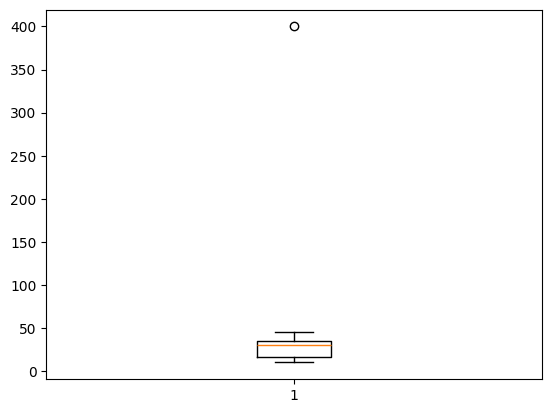

In [61]:
# GERAÇÃO DE BOXPLOT PARA IDADE: VISUALIZAÇÃO DE DISPERSÃO E IDENTIFICAÇÃO VISUAL DE OUTLIERS
plt.boxplot(lista_idades)

{'whiskers': [<matplotlib.lines.Line2D at 0x7ad5c93864e0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ad5c9386ba0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ad5c97fa420>],
 'medians': [<matplotlib.lines.Line2D at 0x7ad5c93871d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ad5c9387560>],
 'means': []}

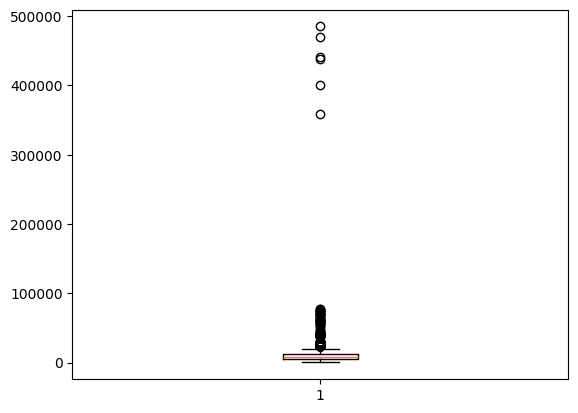

In [62]:
# GERAÇÃO DE BOXPLOT PARA SALÁRIO: ANÁLISE DE DISPERSÃO NA COLUNA SALARIAL
plt.boxplot(dados['SALARIO'])

##ANÁLISE DE DISPERSÃO E LIMITES (MÉTODO IQR)



**OBJETIVO:** utilizar o intervalo interquartil (IQR) para definir o que constitui um dado "normal" versus um dado "discrepante".




In [63]:
# CÁLCULO DO PRIMEIRO QUARTIL (Q1) - 25% DOS DADOS ABAIXO DESTE VALOR
Q1 = dados['SALARIO'].quantile(0.25)

In [64]:
# CÁLCULO DO TERCEIRO QUARTIL (Q3) - 75% DOS DADOS ABAIXO DESTE VALOR
Q3 = dados['SALARIO'].quantile(0.75)

In [65]:
# CÁLCULO DO IQR (AMPLITUDE INTERQUARTIL) PARA DEFINIR A FAIXA DE NORMALIDADE
IQR = Q3 - Q1

In [66]:
# DEFINIÇÃO DO LIMITE SUPERIOR (VALORES ACIMA DESTE SÃO CONSIDERADOS OUTLIERS)
lin_superior = Q3 + (1.5*IQR)

In [67]:
# DEFINIÇÃO DO LIMITE INFERIOR (VALORES ABAIXO DESTE SÃO CONSIDERADOS OUTLIERS)
lin_inferior = Q1 - (1.5*IQR)

##TRATAMENTO DE VALORES DISCREPANTES

**OBJETIVO:** normalizar os dados extremos substituindo-os por valores representativos de suas respectivas categorias.

In [68]:
# CÁLCULO DA MÉDIA GERAL DA COLUNA SALÁRIO
media_salario = dados['SALARIO'].mean()

In [69]:
# CÁLCULO DO DESVIO PADRÃO DA COLUNA SALÁRIO PARA DEFINIR O LIMITE
desvio_salario = dados['SALARIO'].std()

In [70]:
# DEFINIÇÃO DO LIMITE SUPERIOR DE SALÁRIO BASEADO NA MÉDIA E 3 DESVIOS
limite_superior = media_salario + (3*desvio_salario)

In [71]:
# CÁLCULO DA MÉDIA ESPECÍFICA PARA A FAIXA DE R$ 30K-40K (PARA IMPUTAÇÃO)
media_30_40 = dados[(dados['FAIXA SALARIAL']=='de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO']<limite_superior)]['SALARIO'].mean()

In [72]:
# SUBSTITUIÇÃO DOS OUTLIERS DA FAIXA 30K-40K PELA MÉDIA DA PRÓPRIA FAIXA
dados.loc[(dados['FAIXA SALARIAL']=='de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO']>limite_superior), 'SALARIO'] = media_30_40

In [73]:
# CÁLCULO DA MÉDIA ESPECÍFICA PARA A FAIXA ACIMA DE R$ 40K (PARA IMPUTAÇÃO)
media_acima_40 = dados[(dados['FAIXA SALARIAL']=='Acima de R$ 40.001/mês') & (dados['SALARIO']>limite_superior)]['SALARIO'].mean()

In [74]:
# SUBSTITUIÇÃO DOS OUTLIERS DA FAIXA ACIMA DE 40K PELA MÉDIA DA PRÓPRIA FAIXA
dados.loc[(dados['FAIXA SALARIAL']=='Acima de R$ 40.001/mês') & (dados['SALARIO']>limite_superior), 'SALARIO'] = media_acima_40

{'whiskers': [<matplotlib.lines.Line2D at 0x7ad5c93eb2c0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ad5c93eb920>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ad5c93eaf90>],
 'medians': [<matplotlib.lines.Line2D at 0x7ad5c93ebef0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ad5c93f4230>],
 'means': []}

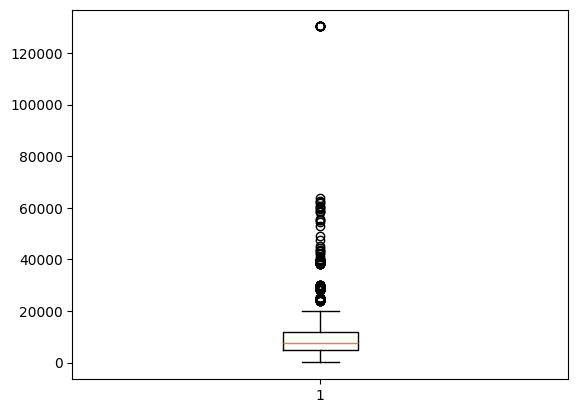

In [75]:
# VISUALIZAÇÃO PÓS-TRATAMENTO PARA VERIFICAR A DISTRIBUIÇÃO DOS DADOS
plt.boxplot(dados['SALARIO'])

##ANÁLISE DE CORRELAÇÃO E ASSOCIAÇÃO ESTATÍSTICA
**OBJETIVO:** mensurar a força e a direção da relação entre variáveis numéricas e categóricas.

In [76]:
# CRIAÇÃO DE TABELA DINÂMICA PARA CRUZAR GÊNERO E CARGOS DE LIDERANÇA
matriz_lideranca = pd.pivot_table(
    dados,
    values='ID',
    index=['GENERO'],
    columns=['GESTOR?'],
    aggfunc='count'
)

In [78]:
# CÁLCULO DA CORRELAÇÃO DE PEARSON ENTRE IDADE E SALÁRIO
correlacao_continua = dados['IDADE'].corr(dados['SALARIO'])
print(f"CORRELAÇÃO DE PEARSON ENTRE IDADE E SALÁRIO: {correlacao_continua}")

CORRELAÇÃO DE PEARSON ENTRE IDADE E SALÁRIO: 0.25193633282011335


In [79]:
# DEFINIÇÃO DE FUNÇÃO PARA CÁLCULO DO COEFICIENTE V DE CRAMER (ASSOCIAÇÃO ENTRE CATEGÓRICAS)
def cramer_coeficiente(coluna1, coluna2):
    # CRIAÇÃO DA TABELA DE CONTINGÊNCIA CRUZANDO AS DUAS VARIÁVEIS
    tabela_cruzada = pd.crosstab(coluna1, coluna2)
    # TESTE QUI-QUADRADO PARA VERIFICAR DEPENDÊNCIA ESTATÍSTICA
    chi2 = chi2_contingency(tabela_cruzada)[0]
    # SOMA DOS VALORES DA TABELA PARA NORMALIZAÇÃO
    soma = np.sum(tabela_cruzada)
    # DIMENSÃO MÍNIMA DA MATRIZ PARA CÁLCULO DO COEFICIENTE
    mini = min(tabela_cruzada.shape) - 1
    # CÁLCULO DO V DE CRAMER (RESULTADO NORMALIZADO ENTRE 0 E 1)
    cramer = np.sqrt(chi2/(soma*mini))
    return cramer

In [83]:
# APLICAÇÃO DO COEFICIENTE V DE CRAMER PARA ANALISAR ETNIA VS NÍVEL DE ENSINO
resultado_cramer = cramer_coeficiente(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])
print(f"RESULTADO DO COEFICIENTE V DE CRAMER: {resultado_cramer}")

RESULTADO DO COEFICIENTE V DE CRAMER: NIVEL DE ENSINO
Doutorado ou Phd              0.212952
Estudante de Graduação        0.118869
Graduação/Bacharelado         0.075737
Mestrado                      0.128937
Não tenho graduação formal    0.280609
Prefiro não informar          0.849585
Pós-graduação                 0.081190
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


##INTEGRAÇÃO DE BASES RELACIONAIS PARA ENRIQUECIMENTO DE DADOS

**OBJETIVO:** Integrar bases de dados relacionais utilizando SQL para enriquecer o dataset principal e ampliar as possibilidades de análise.

In [86]:
# EXTRAÇÃO DOS ESTADOS ÚNICOS PARA CONSULTA PARAMETRIZADA (EVITA ERROS DE SINTAXE)
lista_estados = list(dados['UF ONDE MORA'].unique())

In [87]:
# CONSTRUÇÃO DA QUERY SQL UTILIZANDO JOIN PARA INTEGRAR TABELAS DE MUNICÍPIOS E STATUS DE RENDA
query = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) FROM Municipios_Brasileiros
INNER JOIN Municipio_Status ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
WHERE Municipios_Brasileiros.Estado IN ({})
GROUP BY Municipios_Brasileiros.Estado;'''.format(','.join(['?'] * len(lista_estados)))

In [94]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[]


In [97]:
# EXECUÇÃO DA QUERY E CARREGAMENTO PARA DATAFRAME
estados_renda = pd.read_sql(query, con=conexao, params=lista_estados)

In [98]:
# RENOMEANDO COLUNA PARA FACILITAR A JUNÇÃO (MERGE)
dados.rename(columns={'UF ONDE MORA_x': 'Estado'}, inplace = True)

In [99]:
# JUNÇÃO (MERGE) DO DATASET PRINCIPAL COM OS DADOS DE RENDA OBTIDOS NO SQL
dados = dados.merge(estados_renda, on="Estado", how='left')

# Exibindo as primeiras linhas para confirmar a junção das novas colunas
print("Amostra do Dataset após Integração SQL:")
display(dados.head())

Amostra do Dataset após Integração SQL:


,Unnamed: 0_x,ID,IDADE_x,FAIXA IDADE_x,GENERO_x,COR/RACA/ETNIA_x,PCD_x,EXPERIENCIA_PROFISSIONAL_PREJUDICADA_x,ASPECTOS_PREJUDICADOS_x,VIVE_NO_BRASIL_x,...,FAIXA SALARIAL_y,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?_y,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?_y,SALARIO_y,NOVO_NIVEL_y,NIVEL_Júnior_y,NIVEL_Pleno_y,NIVEL_Sênior_y,GEARACAO_y,AVG(Municipio_Status.renda)
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0,Júnior,True,False,False,Millenial,0.863000
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0,NaN,False,False,False,Millenial,0.572357
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0,Pleno,False,True,False,Geração x,0.863000
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0,Sênior,False,False,True,Geração Z,0.652008
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0,Pleno,False,True,False,Geração x,0.572357


In [101]:
# CÁLCULO DA CORRELAÇÃO ENTRE RENDA E SALÁRIO
correlacao_renda_salario = dados['SALARIO_x'].corr(dados['AVG(Municipio_Status.renda)'])

# Exibindo o resultado da correlação de forma destacada
print(f"Coeficiente de Correlação (Renda vs Salário): {correlacao_renda_salario:.4f}")

Coeficiente de Correlação (Renda vs Salário): 0.1250


##ANÁLISE VISUAL DE DADOS UTILIZANDO GRÁFICOS ESTATÍSTICOS

**OBJETIVO:** Explorar padrões e distribuições dos dados por meio de visualizações gráficas estáticas e interativas.

In [102]:
# PREPARAÇÃO DOS DADOS PARA PLOTAGEM
genero_counts = dados['GENERO_x'].value_counts()
salario_por_idade = dados.groupby('IDADE_x')['SALARIO_x'].mean()

/tmp/ipykernel_73695/1738505035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='GENERO_x', palette='pastel')


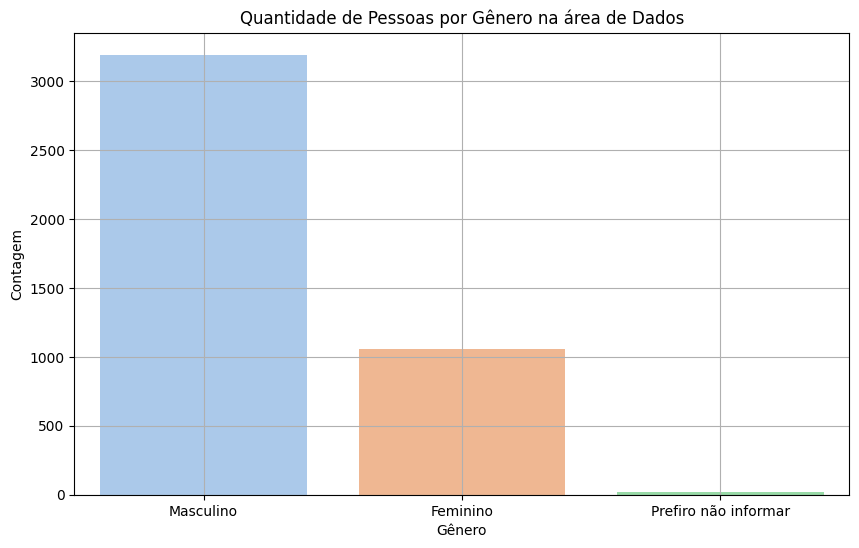

In [109]:
# GRÁFICO DE BARRAS (SEABORN)
plt.figure(figsize=(10, 6))
sns.countplot(data=dados, x='GENERO_x', palette='pastel')
plt.title('Quantidade de Pessoas por Gênero na área de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.grid(True)
plt.show()

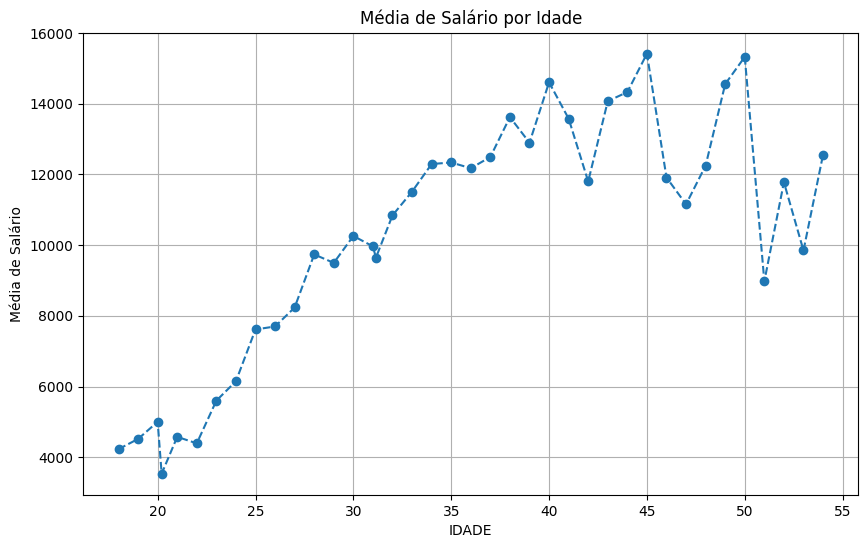

In [110]:
# GRÁFICO DE LINHA (MATPLOTLIB)
plt.figure(figsize=(10, 6))
plt.plot(salario_por_idade.index, salario_por_idade.values, marker='o', linestyle='--')
plt.xlabel('IDADE')
plt.ylabel('Média de Salário')
plt.title('Média de Salário por Idade')
plt.grid(True)
plt.show()

In [112]:
# GRÁFICO DE LINHA INTERATIVO
fig = px.line(salario_por_idade.reset_index(), x='IDADE_x', y='SALARIO_x',
              title='Média de Salário por Idade', markers=True)
fig.show()

In [114]:
# GRÁFICO DE DISPERSÃO INTERATIVO
fig = px.scatter(dados, x='IDADE_x', y='SALARIO_x',
                 title='Dispersão de Salário por Idade')
fig.show()


##CONCLUSÃO

Finalizar essa análise foi um baita aprendizado. Consegui cruzar as informações do DataHackers 2022 e ver de perto como o mercado de tecnologia no Brasil se comporta.

Durante o processo, fiz de tudo um pouco: desde a estatística básica e limpeza dos dados até integrações mais complexas com SQL e visualizações gráficas. Mais do que gerar gráficos, o desafio foi transformar esses dados brutos em insights que façam sentido para o mundo real. No fim das contas, saio com a bagagem cheia de novos aprendizados em análise exploratória e, principalmente, na arte de resolver os problemas que surgem no meio do caminho.